In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Image Augmentation

In that section, 
we mentioned that large datasets 
are a prerequisite
for the success of
deep neural networks
in various applications.
*Image augmentation* 
generates similar but distinct training examples
after a series of random changes to the training images, thereby expanding the size of the training set.
Alternatively,
image augmentation can be motivated
by the fact that 
random tweaks of training examples 
allow models to rely less on
certain attributes, thereby improving their generalization ability.
For example, we can crop an image in different ways to make the object of interest appear in different positions, thereby reducing the dependence of a model on the position of the object. 
We can also adjust factors such as brightness and color to reduce a model's sensitivity to color.
It is probably true
that image augmentation was indispensable
for the success of AlexNet at that time.
In this section we will discuss this widely used technique in computer vision.

In [1]:
%matplotlib inline
import os
# cuDNN's convolution autotuner allocates large transient scratch buffers when
# the input's batch dimension is dynamic -- here the tf.data loader yields a
# variable-size final batch -- spiking the reserved footprint to ~8.6 GiB for
# this ResNet-18 / batch-256 training step. Disabling autotuning falls back to
# cuDNN's default low-memory algorithm (same result), and we cap the workspace
# as a backstop; the true footprint drops to ~4.5 GiB. Set before TF starts
# cuDNN.
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
os.environ['TF_CUDNN_WORKSPACE_LIMIT_IN_MB'] = '2048'
from d2l import tensorflow as d2l
import tensorflow as tf
import keras
from PIL import Image
import numpy as np

## Common Image Augmentation Methods

In our investigation of common image augmentation methods, we will use the following $400\times 500$ image as an example.

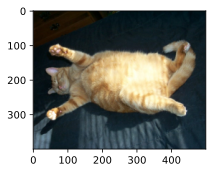

In [2]:
d2l.set_figsize()
img = Image.open('../img/cat1.jpg')
d2l.plt.imshow(img);

Most image augmentation methods have a certain degree of randomness. To make it easier for us to observe the effect of image augmentation, next we define an auxiliary function `apply`. This function runs the image augmentation method `aug` multiple times on the input image `img` and shows all the results.

In [3]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

### Flipping and Cropping

Flipping the image left and right usually does not change the category of the object. 
This is one of the earliest and most widely used methods of image augmentation.
Next, we define a `RandomHorizontalFlip` function using `tf.image`, which flips
an image left and right with a 50% chance. We convert between PIL images and TensorFlow tensors as needed.

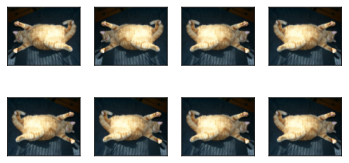

In [4]:
def RandomHorizontalFlip():
    def aug(img):
        img_tf = tf.constant(np.array(img))
        img_tf = tf.image.random_flip_left_right(img_tf)
        return Image.fromarray(img_tf.numpy())
    return aug

apply(img, RandomHorizontalFlip())

Flipping up and down is not as common as flipping left and right. But at least for this example image, flipping up and down does not hinder recognition.
Next, we create a `RandomVerticalFlip` function to flip
an image up and down with a 50% chance.

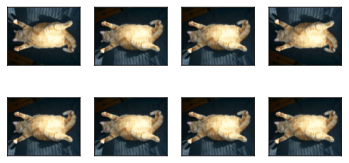

In [5]:
def RandomVerticalFlip():
    def aug(img):
        img_tf = tf.constant(np.array(img))
        img_tf = tf.image.random_flip_up_down(img_tf)
        return Image.fromarray(img_tf.numpy())
    return aug

apply(img, RandomVerticalFlip())

In the example image we used, the cat is in the middle of the image, but this may not be the case in general. 
In that section, we explained that the pooling layer can reduce the sensitivity of a convolutional layer to the target position.
In addition, we can also randomly crop the image to make objects appear in different positions in the image at different scales, which can also reduce the sensitivity of a model to the target position.

In the code below, we randomly crop an area with an area of $10\% \sim 100\%$ of the original area each time, and the ratio of width to height of this area is randomly selected from $0.5 \sim 2$. Then, the width and height of the region are both scaled to 200 pixels. 
Unless otherwise specified, the random number between $a$ and $b$ in this section refers to a continuous value obtained by random and uniform sampling from the interval $[a, b]$.

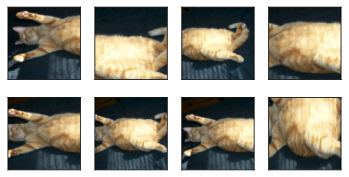

In [6]:
def RandomResizedCrop(size, scale=(0.1, 1), ratio=(0.5, 2)):
    target_h, target_w = size
    def aug(img):
        img_tf = tf.constant(np.array(img))
        h, w = tf.shape(img_tf)[0], tf.shape(img_tf)[1]
        area = tf.cast(h * w, tf.float32)
        log_ratio = (tf.math.log(float(ratio[0])), tf.math.log(float(ratio[1])))
        target_area = tf.random.uniform([], scale[0], scale[1]) * area
        aspect = tf.exp(tf.random.uniform([], log_ratio[0], log_ratio[1]))
        crop_h = tf.cast(tf.round(tf.sqrt(target_area / aspect)), tf.int32)
        crop_w = tf.cast(tf.round(tf.sqrt(target_area * aspect)), tf.int32)
        crop_h = tf.minimum(crop_h, h)
        crop_w = tf.minimum(crop_w, w)
        offset_h = tf.random.uniform([], 0, h - crop_h + 1, dtype=tf.int32)
        offset_w = tf.random.uniform([], 0, w - crop_w + 1, dtype=tf.int32)
        img_tf = tf.image.crop_to_bounding_box(img_tf, offset_h, offset_w,
                                                crop_h, crop_w)
        img_tf = tf.cast(img_tf, tf.float32)
        img_tf = tf.image.resize(img_tf, [target_h, target_w])
        img_tf = tf.cast(img_tf, tf.uint8)
        return Image.fromarray(img_tf.numpy())
    return aug

shape_aug = RandomResizedCrop((200, 200), scale=(0.1, 1), ratio=(0.5, 2))
apply(img, shape_aug)

### Changing Colors

Another augmentation method is changing colors. We can change four aspects of the image color: brightness, contrast, saturation, and hue. In the example below, we randomly change the brightness of the image to a value between 50% ($1-0.5$) and 150% ($1+0.5$) of the original image.

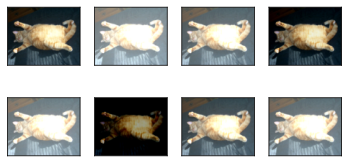

In [7]:
def RandomBrightness(max_delta):
    def aug(img):
        img_tf = tf.cast(tf.constant(np.array(img)), tf.float32) / 255.0
        img_tf = tf.image.random_brightness(img_tf, max_delta)
        img_tf = tf.clip_by_value(img_tf, 0.0, 1.0)
        return Image.fromarray((img_tf.numpy() * 255).astype(np.uint8))
    return aug

apply(img, RandomBrightness(0.5))

Similarly, we can randomly change the hue of the image.

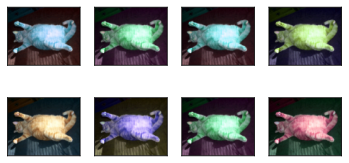

In [8]:
def RandomHue(max_delta):
    def aug(img):
        img_tf = tf.cast(tf.constant(np.array(img)), tf.float32) / 255.0
        img_tf = tf.image.random_hue(img_tf, max_delta)
        img_tf = tf.clip_by_value(img_tf, 0.0, 1.0)
        return Image.fromarray((img_tf.numpy() * 255).astype(np.uint8))
    return aug

apply(img, RandomHue(0.5))

We can also create a `RandomColorJitter` instance and set how to randomly change the `brightness`, `contrast`, `saturation`, and `hue` of the image at the same time.

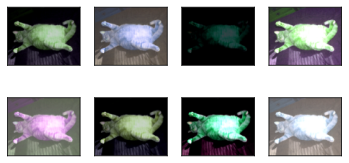

In [9]:
def RandomColorJitter(brightness=0, contrast=0, saturation=0, hue=0):
    def aug(img):
        img_tf = tf.cast(tf.constant(np.array(img)), tf.float32) / 255.0
        if brightness > 0:
            img_tf = tf.image.random_brightness(img_tf, brightness)
        if contrast > 0:
            img_tf = tf.image.random_contrast(img_tf, 1 - contrast,
                                              1 + contrast)
        if saturation > 0:
            img_tf = tf.image.random_saturation(img_tf, 1 - saturation,
                                                1 + saturation)
        if hue > 0:
            img_tf = tf.image.random_hue(img_tf, hue)
        img_tf = tf.clip_by_value(img_tf, 0.0, 1.0)
        return Image.fromarray((img_tf.numpy() * 255).astype(np.uint8))
    return aug

color_aug = RandomColorJitter(brightness=0.5, contrast=0.5, saturation=0.5,
                              hue=0.5)
apply(img, color_aug)

### Combining Multiple Image Augmentation Methods

In practice, we will combine multiple image augmentation methods. 
For example,
we can combine the different image augmentation methods defined above and apply them to each image via a `Compose` instance.

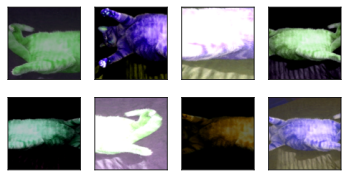

In [10]:
def Compose(transforms):
    def aug(img):
        for t in transforms:
            img = t(img)
        return img
    return aug

augs = Compose([RandomHorizontalFlip(), color_aug, shape_aug])
apply(img, augs)

## Training with Image Augmentation

Let's train a model with image augmentation.
Here we use the CIFAR-10 dataset instead of the Fashion-MNIST dataset that we used before. 
This is because the position and size of the objects in the Fashion-MNIST dataset have been normalized, while the color and size of the objects in the CIFAR-10 dataset have more significant differences. 
The first 32 training images in the CIFAR-10 dataset are shown below.

/home/smola/d2l-neu/.venv-tensorflow/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


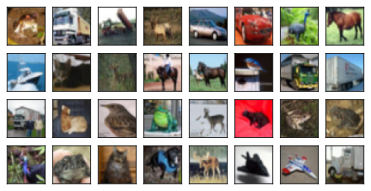

In [11]:
(train_images, train_labels), _ = keras.datasets.cifar10.load_data()
d2l.show_images([Image.fromarray(train_images[i]) for i in range(32)],
                4, 8, scale=0.8);

In order to obtain definitive results during prediction, we usually only apply image augmentation to training examples, and do not use image augmentation with random operations during prediction. 
Here we only use the simplest random left-right flipping method. In addition, we use a `ToTensor` instance to convert a minibatch of images into the format required by the deep learning framework, i.e., 
32-bit floating point numbers between 0 and 1 with the shape of (batch size, number of channels, height, width).

In [12]:
def train_augs(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    return image, label

def test_augs(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

Next, we define an auxiliary function to facilitate reading the image and
applying image augmentation.
We use `keras.datasets` to load CIFAR-10 and `tf.data.Dataset` for batching
and preprocessing.
For
a detailed introduction to data loading, please refer to that section.

In [13]:
def load_cifar10(is_train, aug_fn, batch_size):
    (train_imgs, train_lbls), (test_imgs, test_lbls) = (
        keras.datasets.cifar10.load_data())
    if is_train:
        images, labels = train_imgs, train_lbls.squeeze()
    else:
        images, labels = test_imgs, test_lbls.squeeze()
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if is_train:
        ds = ds.shuffle(10000)
    ds = ds.map(aug_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

### Multi-GPU Training

We train the ResNet-18 model from
that section on the
CIFAR-10 dataset.
Recall the introduction to
multi-GPU training in that section.
In the following,
we define a function to train and evaluate the model using multiple GPUs.

In [14]:

def train_batch_ch13(net, X, y, loss, optimizer):
    """Train for a minibatch with Keras (defined in Chapter 13)."""
    with tf.GradientTape() as tape:
        pred = net(X, training=True)
        l = loss(y, pred)
    grads = tape.gradient(l, net.trainable_variables)
    optimizer.apply_gradients(zip(grads, net.trainable_variables))
    train_loss_sum = tf.reduce_sum(l)
    train_acc_sum = tf.reduce_sum(
        tf.cast(tf.argmax(pred, axis=1) == tf.cast(y, tf.int64), tf.float32))
    return train_loss_sum, train_acc_sum

In [15]:

def train_ch13(net, train_iter, test_iter, loss, optimizer, num_epochs):
    """Train a model with Keras (defined in Chapter 13)."""
    num_batches = sum(1 for _ in train_iter)
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                            legend=['train loss', 'train acc', 'test acc'])
    timer = d2l.Timer()
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of examples
        metric = d2l.Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(net, features, labels, loss, optimizer)
            n = features.shape[0]
            metric.add(float(l), float(acc), n, n)
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3],
                              None))
        # Evaluate on test set
        correct, total = 0, 0
        for X, y in test_iter:
            logits = net(X, training=False)
            correct += int(tf.reduce_sum(tf.cast(
                tf.argmax(logits, axis=1) == tf.cast(y, tf.int64),
                tf.float32)))
            total += y.shape[0]
        test_acc = correct / total
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc '
          f'{metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec')

Now we can define the `train_with_data_aug` function to train the model with image augmentation.
This function gets all available GPUs, 
uses Adam as the optimization algorithm,
applies image augmentation to the training dataset,
and finally calls the `train_ch13` function just defined to train and evaluate the model.

In [16]:
batch_size = 256

def get_net_tf():
    return d2l.resnet18(10, 3)

def train_with_data_aug(train_aug_fn, test_aug_fn, net, lr=0.001):
    train_iter = load_cifar10(True, train_aug_fn, batch_size)
    test_iter = load_cifar10(False, test_aug_fn, batch_size)
    loss = keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction='none')
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    train_ch13(net, train_iter, test_iter, loss, optimizer, 10)

net = get_net_tf()

Let's train the model using image augmentation based on random left-right flipping.

loss 0.181, train acc 0.938, test acc 0.804
710.0 examples/sec


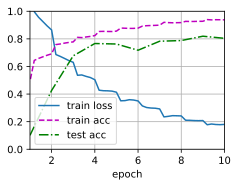

In [17]:
train_with_data_aug(train_augs, test_augs, net)

## Summary

* Image augmentation generates random images based on existing training data to improve the generalization ability of models.
* In order to obtain definitive results during prediction, we usually only apply image augmentation to training examples, and do not use image augmentation with random operations during prediction.
* Deep learning frameworks provide many different image augmentation methods, which can be applied simultaneously.


## Exercises

1. Train the model without using image augmentation: `train_with_data_aug(test_augs, test_augs)`. Compare training and testing accuracy when using and not using image augmentation. Can this comparative experiment support the argument that image augmentation can mitigate overfitting? Why?
1. Combine multiple different image augmentation methods in model training on the CIFAR-10 dataset. Does it improve test accuracy? 
1. Refer to the online documentation of the deep learning framework. What other image augmentation methods does it also provide?

[Discussions](https://d2l.discourse.group/t/1404)